<a href="https://colab.research.google.com/github/EGKIP/Course-Catalog-Automation/blob/main/Assignment_2_Emmanuel_Kiprotich.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CS 435-02 Advanced Deep Learning
## Assignment 2
## Building a Convolutional Autoencoder to classify images in the Fashion-MINIST Dataset

We will work with the Fashion-MINIST Dataset.  This is a well-known dataset for image classification, which consists of 60000 28x28 gray images in 10 classes. There are 60000 training images and 10000 test images.

The 10 classes are:

<ol start="0">
<li> Shirt
<li> T-Shirt/Top
<li> T-Shirt/Top
<li> Ankle boot
<li> Sandal
<li> Dress
<li> Sneaker
<li> Trouser
<li> Bag
<li> Coat
</ol>

For details about Fashion-MINIST see:
https://github.com/zalandoresearch/fashion-mnist


### Building Vanila Autoencoder, Convolutional Autoencoder, variational autoencoder and denoising autoencoder

In this exercise we will build and train our first Simple Vanila autoencoder.  In the first part, we walk through the different layers and how they are configured.  In the second part, you will build your own model, train it, and compare the performance.

What is an AUTOENCODER ?

Autoencoders are a type of neural network that attempts to mimic its input as closely as possible to its output.
It has aims to take an input, transform it into a reduced representation called Embedding or Latent Space representation. Then, this embedding is transformed back into the original input.

**Architecture of Autoencoders**
An Autoencoder consists of three main components :

*   Encoder
*   Embedding (Bottleneck)
*   Decoder

![Google's logo](https://miro.medium.com/max/3110/0*uq2_ZipB9TqI9G_k)

**Types of Autoencoders :**
1.   Vanilla Autoencoder
2.   Convolutional Autoencoder
3.   Denoising Autoencoder
4.   Variational Autoencoder

etc...

In [5]:
# loading improtant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Dense, Input, Flatten,\
Conv2DTranspose, BatchNormalization, LeakyReLU, Reshape, MaxPooling2D, UpSampling2D, Activation
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.datasets import fashion_mnist
import tensorflow.keras.backend as K
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adadelta
import tensorflow as tf
import tensorflow_datasets as tfds
import plotly
import plotly.express as px

In [6]:
# The data, shuffled and split between train and test sets:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train.astype("float32")/255.
x_test = x_test.astype("float32")/255.
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (60000, 28, 28)
60000 train samples
10000 test samples


Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


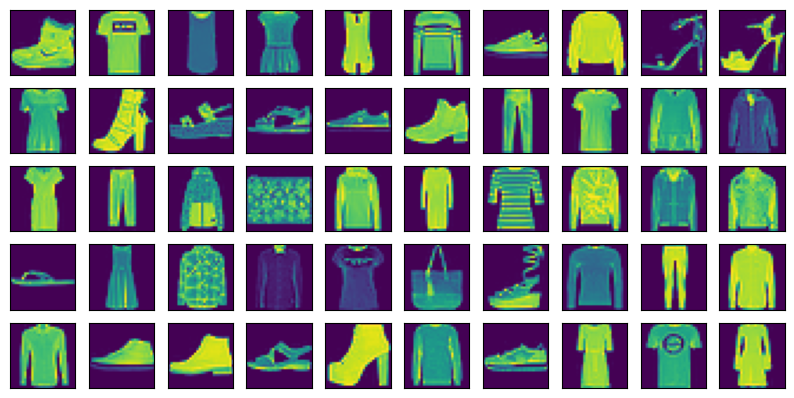

In [7]:
# Ploting the original images
print('Train: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Test: X=%s, y=%s' % (x_test.shape, y_test.shape))

plt.figure(figsize=(10,10))
for index in range(50):
    plt.subplot(10,10,index+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[index])
plt.show()

In [8]:
fashionMNIST_classes = {0:"T-shirt/top", 1:"Trouser",
                        2:"Pullover", 3:"Dress",
                        4:"Coat", 5:"Sandal",
                        6:"Shirt", 7:"Sneaker",
                        8:"Bag", 9:"Ankle boot"}

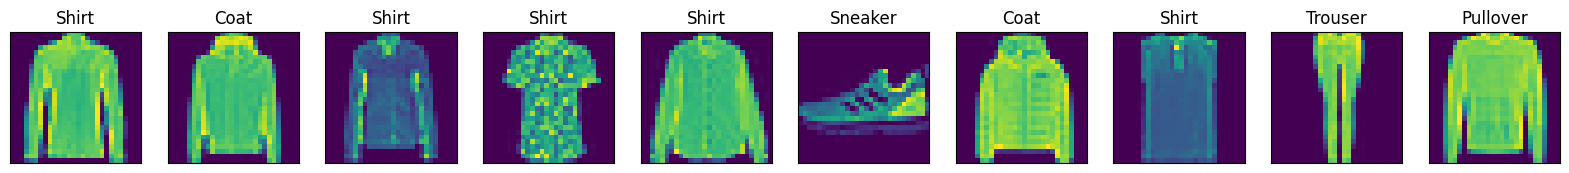

In [9]:
n = 10
plt.figure(figsize = (20, 4))
for i in range(n):
    plt.subplot(1, n, i+1)
    idx = np.random.randint(i, len(x_train))
    plt.imshow(x_train[idx])
    plt.title(fashionMNIST_classes[y_train[idx]])
    #plt.gray()
    plt.xticks([]); plt.yticks([])
plt.show()

**First Building Vanila Autoencoder**

A Vanilla Autoencoder is a straightforward yet powerful framework for unsupervised learning tasks. It consists of two main components: an encoder and a decoder. These components work together to compress input data into a lower-dimensional representation and then reconstruct the data.

Training a Vanilla Autoencoder involves minimizing the reconstruction error, which measures the difference between the original input data and the reconstructed output.

This process is typically achieved through backpropagation, where the gradients of the reconstruction error with respect to the model parameters are calculated. These gradients are then used to update the weights of the neural network layers.

The goal is to optimize the parameters so that the reconstructed output closely resembles the original input.




In [10]:
# Vanilla Autoencoder

encoding_dim = 64  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# This is our input image (encoder layer)
input_img = tf.keras.Input(shape=(28,28))
# "encoded" is the encoded representation of the input (latent space layer)
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input (decoder)
decoded = layers.Dense(28, activation='sigmoid')(encoded)


# This model maps an input to its reconstruction
autoencoder = tf.keras.Model(input_img, decoded)

In [11]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 28, 64)              │           1,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 28, 28)              │           1,820 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,676 (14.36 KB)

 Trainable params: 3,676 (14.36 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [13]:
history = autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.5524 - val_loss: 0.3124
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2951 - val_loss: 0.2745
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2691 - val_loss: 0.2636
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2596 - val_loss: 0.2582
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2555 - val_loss: 0.2556
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2536 - val_loss: 0.2539
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2513 - val_loss: 0.2528
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2508 - val_loss: 0.2520
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2499 - val_loss: 0.2514
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2489 - val_loss: 0.2509


In [14]:
# Checking the test results.
# The Test score is in the format of loss, mean absolute error and accuracy
score = autoencoder.evaluate(x_test, x_test)
print(score)
prediction_data = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2509
0.250875860452652
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


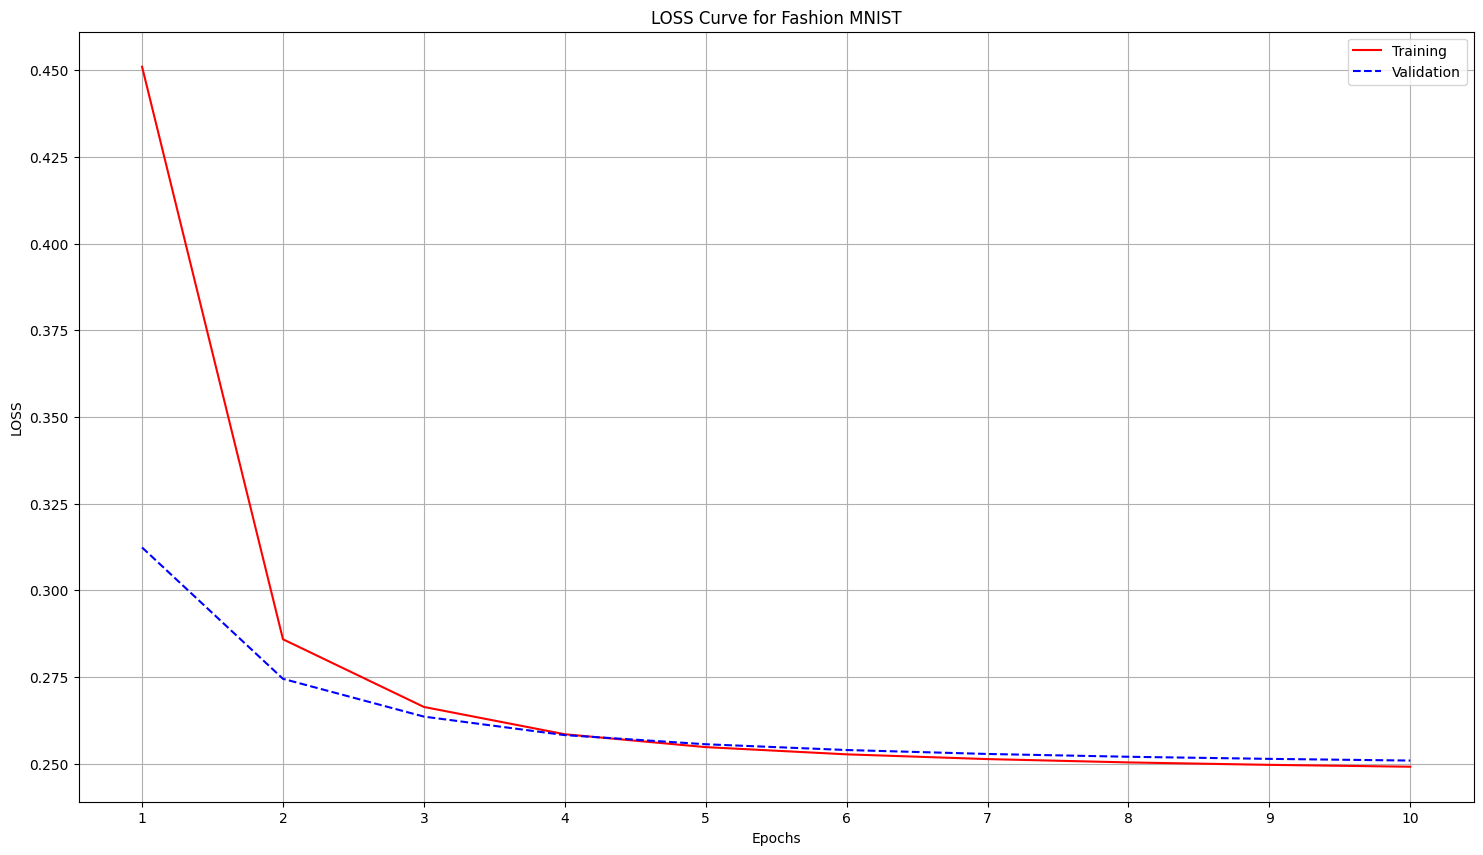

In [15]:
# Storing our training and validation losses
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = [d for d in range(1,11)]

# Code for plotting train and val loss
plt.figure(figsize=(18, 10))
plt.plot(epochs, train_loss, '-r', label="Training")
plt.plot(epochs, val_loss, '--b', label="Validation")
plt.title("LOSS Curve for Fashion MNIST")
plt.grid(True)
plt.xlabel('Epochs'); plt.ylabel("LOSS")
plt.legend()
plt.xticks([d for d in range(1, 11)])
plt.show();

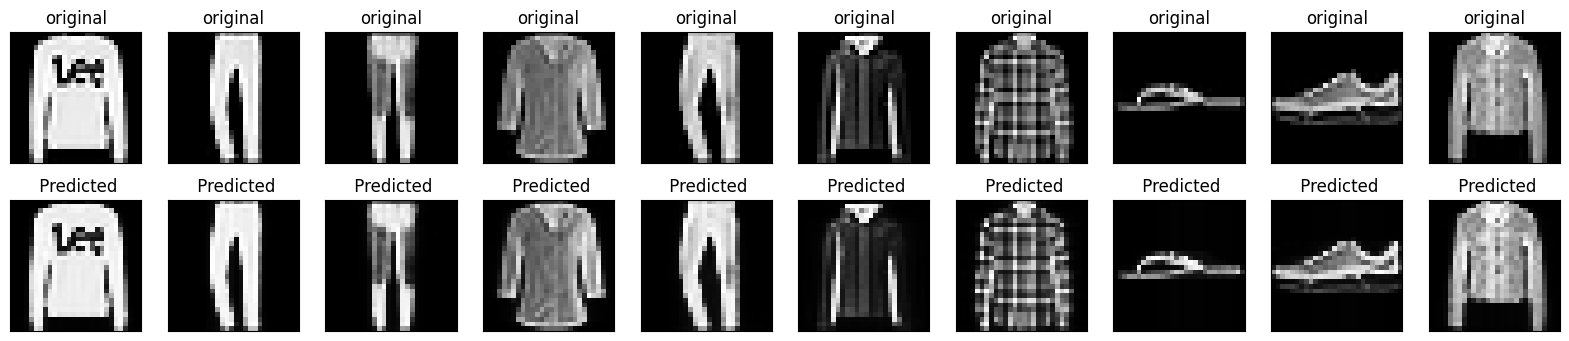

In [16]:
# collecting the encoded and decoded versions of our test data
# Showing the original and predicted images of all 10 classes.
n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    plt.title('original')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(prediction_data[i].reshape(28,28))
    plt.gray()
    plt.title(' Predicted')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Convolutional Autoencoder

Convolutional autoencoders are specifically designed to handle high-dimensional data with spatial structures, such as images. They utilize convolutional layers to capture spatial dependencies and hierarchical features within the input data. This architecture allows them to efficiently encode and decode complex patterns, making them particularly well-suited for tasks such as image reconstruction, denoising, and feature extraction.

Training convolutional autoencoders involves optimizing the model parameters to minimize the reconstruction error between the input and output data. This process is typically achieved through backpropagation and gradient descent, where the weights of the convolutional and fully connected layers are iteratively adjusted to minimize the loss function. Common loss functions used include mean squared error (MSE) or binary cross-entropy, depending on the nature of the input data.

In [17]:
# Let's build a CNN using Keras' Sequential capabilities
# As we know that CNN are good for image classification. We can use Convolution 2D for our encoder and decoder layers.

input_img = tf.keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# at this point the representation is (4, 4, 8) i.e. 128-dimensional

x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation='relu')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencodercnn = tf.keras.Model(input_img, decoded)
autoencodercnn.compile(optimizer='adam', loss='binary_crossentropy')

In [18]:
autoencodercnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 8)           │           1,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 8, 8, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 16, 16, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 16)          │           1,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_2 (UpSampling2D)       │ (None, 28, 28, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 1)           │             145 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:

history_cnn = autoencodercnn.fit(x_train, x_train,
                    batch_size=32,
                    epochs=15,
                    verbose=1,
                    validation_data=(x_test, x_test),
                    shuffle=True)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.3609 - val_loss: 0.2976
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2936 - val_loss: 0.2918
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.2884 - val_loss: 0.2892
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2864 - val_loss: 0.2868
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2839 - val_loss: 0.2849
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2823 - val_loss: 0.2836
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2818 - val_loss: 0.2826
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.2809 - val_loss: 0.2820
Epoch 9/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2797 - val_loss: 0.2815
Epoch 10/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.2784 - val_loss: 0.2811
Epoch 11/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2785 - val_loss: 0.2805
Epoch 12/15
1875/1875 ━━━━

In [20]:
# Checking the test results.
# The Test score is in the format of loss, mean absolute error and accuracy
score = autoencodercnn.evaluate(x_test, x_test)
print(score)
prediction_data_cnn = autoencodercnn.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2798
0.27988970279693604
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


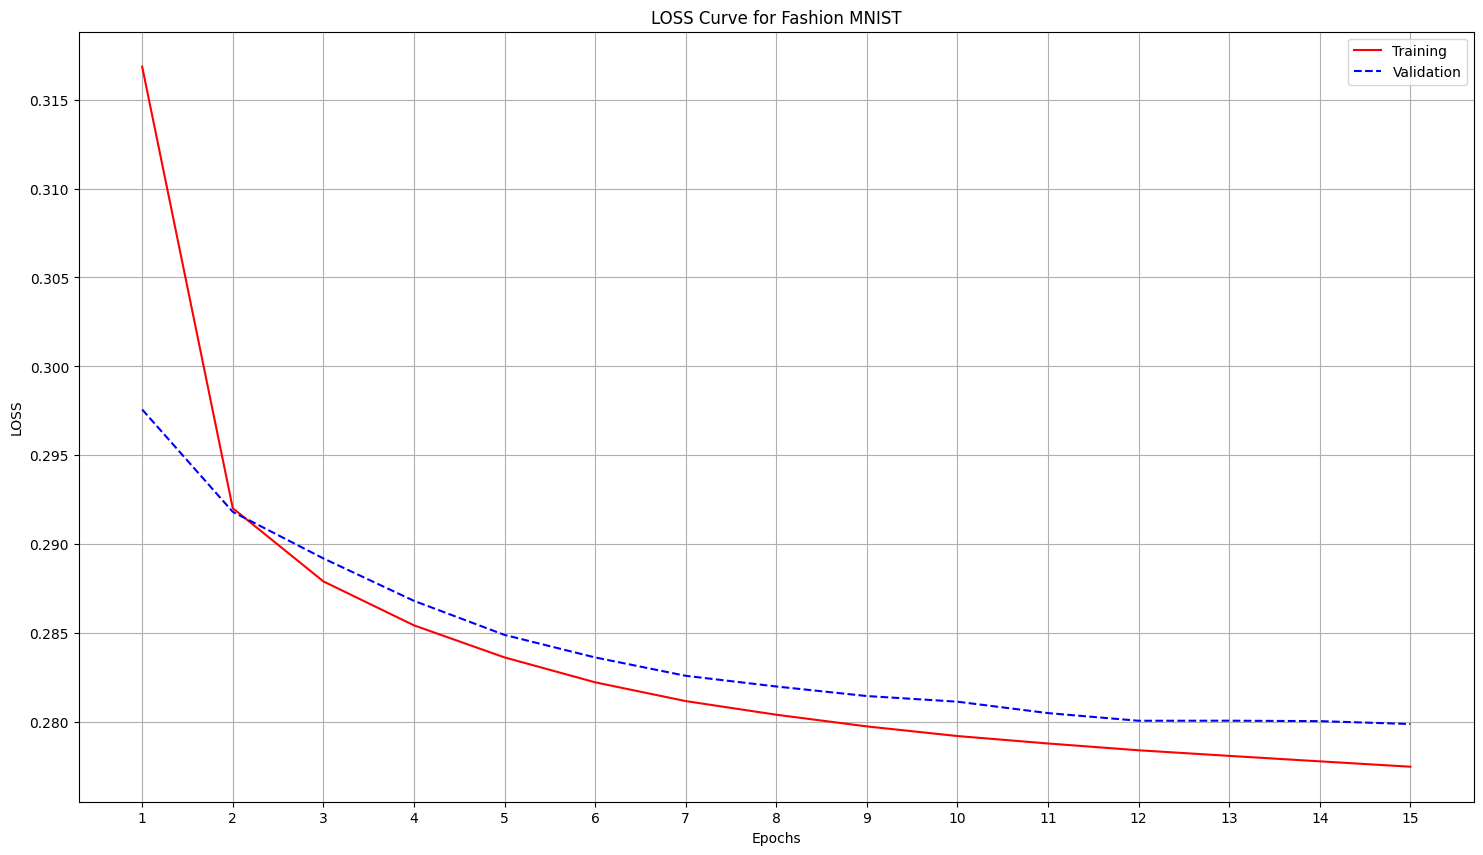

In [21]:
# Storing our training and validation losses
train_loss_cnn = history_cnn.history["loss"]
val_loss_cnn = history_cnn.history["val_loss"]
epochs = [d for d in range(1,16)]

# Code for plotting train and val loss
plt.figure(figsize=(18, 10))
plt.plot(epochs, train_loss_cnn, '-r', label="Training")
plt.plot(epochs, val_loss_cnn, '--b', label="Validation")
plt.title("LOSS Curve for Fashion MNIST")
plt.grid(True)
plt.xlabel('Epochs'); plt.ylabel("LOSS")
plt.legend()
plt.xticks([d for d in range(1, 16)])
plt.show();

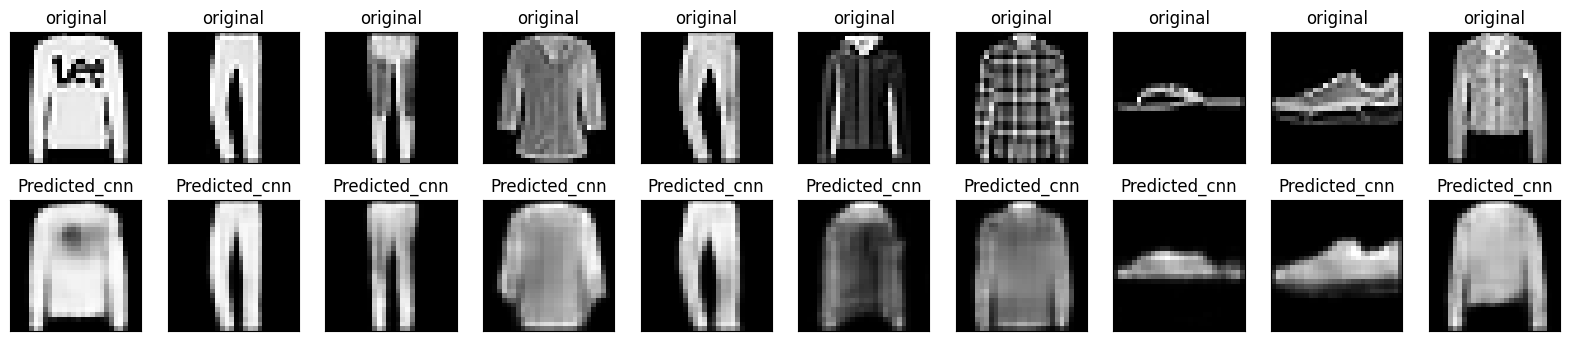

In [22]:
# Showing the original and predicted images of all 10 classes.
n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test[i].reshape(28,28))
    plt.gray()
    plt.title('original')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(prediction_data_cnn[i].reshape(28,28))
    plt.gray()
    plt.title('Predicted_cnn')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### Exercise_1 on Deep Convolutional_autoencoder

---



1. Build a more complicated model with the following pattern:
- Conv -> Conv -> MaxPool -> Conv -> bootlneck -> Conv -> Conv -> Conv -> MaxPool -> Conv

2. How many parameters does your model have?  How does that compare to the previous model?

3. Train it for 15 epochs.  What do you notice about the training time, loss and accuracy numbers (on both the training and validation sets)?

In [23]:
# Please provide your solution here
# Create model_1 to show results
# also plot the original and reconstructed images
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Input
from tensorflow.keras.models import Model

input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)

# Bottleneck
encoded = Conv2D(128, (3, 3), activation='relu', padding='same')(x)

# Decoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((4, 4))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

model_1 = Model(input_img, decoded)
model_1.compile(optimizer='adam', loss='binary_crossentropy')
model_1.summary()

# Train the model
model_1.fit(x_train, x_train, epochs=15, batch_size=64, validation_data=(x_test, x_test))


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 14, 14, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 14, 14, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 7, 7, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_3 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 268,321 (1.02 MB)

 Trainable params: 268,321 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - loss: 0.3392 - val_loss: 0.2809
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.2780 - val_loss: 0.2782
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.2735 - val_loss: 0.2740
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.2718 - val_loss: 0.2733
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.2706 - val_loss: 0.2755
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.2695 - val_loss: 0.2718
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.2686 - val_loss: 0.2712
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.2671 - val_loss: 0.2698
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.2674 - val_loss: 0.2692
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.2666 - val_loss: 0.2685
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.2663 - val_loss: 0.2684
Epoch 12/15
938/938 ━━━━━━━━━━━━━━

# Denoising Autoencoder
A denoising autoencoder is a modification of the original autoencoder in which instead of giving the original input we give a corrupted or noisy version of input to the encoder while decoder loss is calculated concerning original input only. This results in efficient learning of autoencoders and the risk of autoencoder becoming an identity function is significantly reduced.

It consists of two main components:

Encoder:
The encoder is a neural network with one or more hidden layers.
It receives noisy input data instead of the original input and generates an encoding in a low-dimensional space.
There are several ways to generate a corrupted input. The most common being adding a Gaussian noise or randomly masking some of the inputs.

Decoder:
Similar to encoders, decoders are implemented as neural networks with one or more hidden layers.
It takes the encoding generated by the encoder as input and reconstructs the original data.
When calculating the Loss function it compares the output values with the original input, not with the corrupted input.

In [24]:
# loading the dataset
(x_train_n, y_train), (x_test_n, y_test) = fashion_mnist.load_data()

x_train_n = x_train.astype('float32') / 255.
x_test_n = x_test.astype('float32') / 255.
x_train_n = np.reshape(x_train_n, (len(x_train_n), 28,28,1))
x_test_n = np.reshape(x_test_n, (len(x_test_n), 28,28,1))

# adding noise to the original images
noise_factor = 0.001
x_train_noisy = x_train_n + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_n.shape)
x_test_noisy = x_test_n + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_n.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

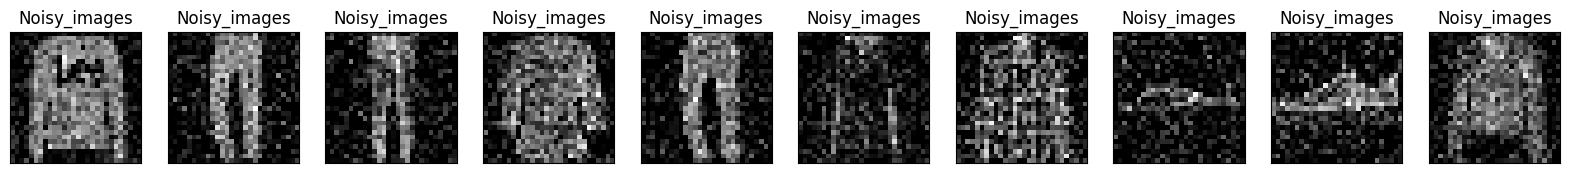

In [25]:
# plotting the noisy images.
n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(x_test_noisy[i].reshape(28,28))
    plt.gray()
    plt.title('Noisy_images')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [26]:
input_img = tf.keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# At this point the representation is (7, 7, 32)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_noisy = tf.keras.Model(input_img, decoded)
autoencoder_noisy.compile(optimizer='adam', loss='binary_crossentropy')

In [27]:
autoencoder_noisy.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 14, 14, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 7, 7, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 7, 7, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_4 (UpSampling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 14, 14, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_5 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Training the model using noisy input to check if autoencoder learn to recover the original images.
history_noisy = autoencoder_noisy.fit(x_train_noisy, x_train,
                    batch_size=64,
                    epochs=5,
                    verbose=1,
                    validation_data=(x_test_noisy, x_test),
                    shuffle=True)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.4639 - val_loss: 0.3112
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3029 - val_loss: 0.2991
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2944 - val_loss: 0.2922
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2897 - val_loss: 0.2897
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2868 - val_loss: 0.2867


In [29]:
# Checking the test results.
# The Test score is in the format of loss, mean absolute error and accuracy
score = autoencoder_noisy.evaluate(x_test_noisy, x_test)
print(score)
prediction_data_noisy = autoencoder_noisy.predict(x_test_noisy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2869
0.28674057126045227
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


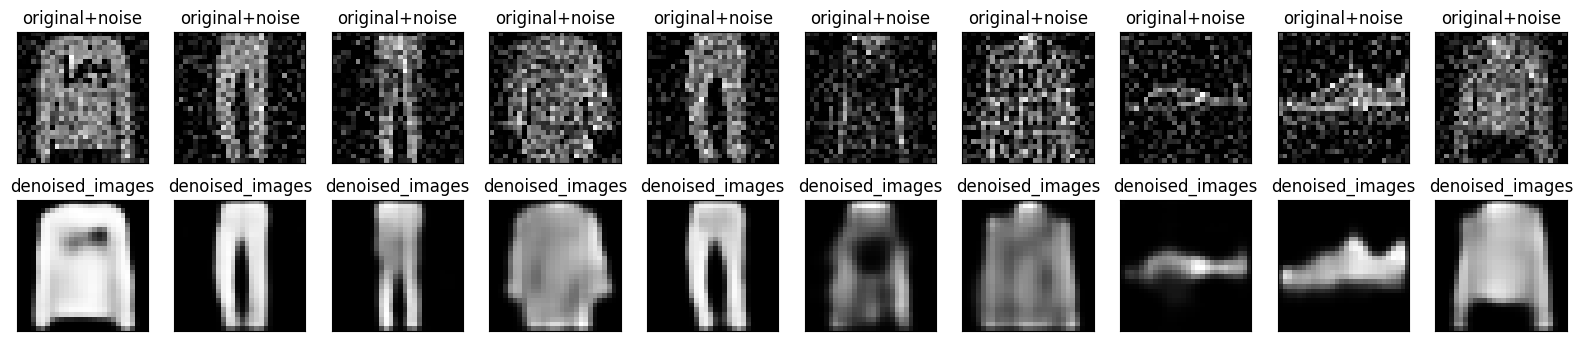

In [30]:
# Showing the original and predicted images of all 10 classes.
n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test_noisy[i].reshape(28,28))
    plt.gray()
    plt.title('original+noise')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(prediction_data_noisy[i].reshape(28,28))
    plt.gray()
    plt.title('denoised_images')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### Exercise_2 on Denoising_autoencoder

---



1. Build a more complicated model based on your understnading that gives more accuracte model than the above denoising model.

2. How many parameters does your model have?  How does that compare to the previous model?

3. Train it for 15 epochs.  What do you notice about the training time, loss and accuracy numbers (on both the training and validation sets)?

4. Change the noise factor between the range of 0 to 1 and compare the difference in denoised images.

In [31]:
# Please provide your solution here
# Create model_2 to show results
# also plot the original and reconstructed images
# Preparing noisy data
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Improved Denoising Autoencoder
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

model_2 = Model(input_img, decoded)
model_2.compile(optimizer='adam', loss='binary_crossentropy')
model_2.summary()

# Train the model
model_2.fit(x_train_noisy, x_train, epochs=15, batch_size=64, validation_data=(x_test_noisy, x_test))


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 28, 28, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 7, 7, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_6 (UpSampling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 14, 14, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_7 (UpSampling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 28, 28, 1)           │             577 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 296,449 (1.13 MB)

 Trainable params: 296,449 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.3402 - val_loss: 0.2999
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 0.2959 - val_loss: 0.2942
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.2915 - val_loss: 0.2919
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.2887 - val_loss: 0.2901
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.2872 - val_loss: 0.2888
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.2858 - val_loss: 0.2880
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.2850 - val_loss: 0.2880
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.2848 - val_loss: 0.2874
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.2845 - val_loss: 0.2869
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.2837 - val_loss: 0.2869
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.2841 - val_loss: 0.2864
Epoch 12/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 

# **Variational Autoencoder **

Variational Autoencoders (VAEs) are generative models in machine learning (ML) that create new data similar to the input they are trained on. Along with data generation they also perform common autoencoder tasks like denoising. Like all autoencoders VAEs consist of:

*   Encoder: Learns important patterns (latent variables) from input data.
*   Decoder: It uses those latent variables to reconstruct the input.

![Google's logo](https://media.geeksforgeeks.org/wp-content/uploads/20231201153426/Variational-AutoEncoder.png)

You can read more about the archiecture and calcuation from https://www.geeksforgeeks.org/variational-autoencoders/




In [32]:
# Loading the data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# Define the latent space dimension
latent_dim = 2


In [33]:
# defining the bottlnenck layer
def sampling(args):
  mean, logvar = args
  eps = K.random_normal([latent_dim])
  rnd_sam = mean + K.exp(logvar/2) * eps
  return rnd_sam

In [34]:
# Create encoder
enc_input = Input(shape=(28,28,1), name='encoder input')
x = Conv2D(128, 5, padding='same', activation='relu')(enc_input)
x = Conv2D(64, 3, padding='same', strides=2, activation='relu')(x)
x = Conv2D(64, 3, padding='same', activation='relu')(x)
x = Conv2D(64, 3, padding='same', activation='relu')(x)
enc_shape = (x.shape)
x = Flatten()(x)
x = Dense(32)(x)

z_mean = Dense(latent_dim, name='Z-mean')(x)
z_logvar = Dense(latent_dim, name='Z-logvariance')(x)

z = layers.Lambda(sampling, output_shape=(latent_dim,), name='latent-space')([z_mean, z_logvar])
encoder = tf.keras.Model(enc_input, z, name='encoder')

# Create decoder
dec_input = Input(shape=(latent_dim,), name='decoder-input')

true_shape = enc_shape[1:]

y = Dense(np.prod(true_shape))(dec_input)
y = Reshape(target_shape=true_shape)(y)
y = Conv2DTranspose(64, 3, padding='same', activation='relu')(y)
y = Conv2DTranspose(64, 3, padding='same', activation='relu')(y)
y = Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(y)
y = Conv2DTranspose(128, 5, padding='same', activation='relu')(y)
y = Conv2DTranspose(1, 5, padding='same', activation='relu')(y)
decoder = tf.keras.Model(dec_input, y, name='decoder')

enc_output = encoder(enc_input)
dec_output = decoder(enc_output)

vae = tf.keras.Model(enc_input, dec_output, name='VAE')
vae.summary()
# You can also print encoder and decoder summary using encoder.summary() to see the total parameters in encoder and decoder

Model: "VAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder input (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder (Functional)                 │ (None, 2)                   │         552,548 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Functional)                 │ (None, 28, 28, 1)           │         356,545 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 909,093 (3.47 MB)

 Trainable params: 909,093 (3.47 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# definign loss function to calculate reconstrction loss.
def loss_func(z_mean, z_logvar):

    def vae_reconstruction_loss(y_true, y_predict):
        reconstruction_loss_factor = 100
        reconstruction_loss = K.mean(K.square(y_true-y_predict), axis=[1, ])
        return reconstruction_loss_factor * reconstruction_loss

    def vae_kl_loss(z_mean, z_logvar):
        kl_loss = -0.5 * K.sum(1.0 + z_logvar - K.square(z_mean) - K.exp(z_logvar), axis=1)
        return kl_loss

    def vae_kl_loss_metric(y_true, y_predict):
        kl_loss = -0.5 * K.sum(1.0 + z_logvar - K.square(z_mean) - K.exp(z_logvar), axis=1)
        return kl_loss

    def vae_loss(y_true, y_predict):
        reconstruction_loss = vae_reconstruction_loss(y_true, y_predict)
        kl_loss = vae_kl_loss(y_true, y_predict)

        loss = reconstruction_loss + kl_loss
        return loss

    return vae_loss

In [36]:
# Create and train the VAE
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
vae.compile(optimizer=opt, loss=loss_func(z_mean, z_logvar))

In [37]:
#X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
#X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))

history_vae = vae.fit(X_train,X_train, epochs=50, batch_size=32, validation_data=(X_test,X_test))

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - loss: 10.0446 - val_loss: 7.6409
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 14ms/step - loss: 7.6235 - val_loss: 7.4939
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7.4783 - val_loss: 7.4760
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 7.3767 - val_loss: 7.3355
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7.3269 - val_loss: 7.2632
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 7.2499 - val_loss: 7.2443
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - loss: 7.2381 - val_loss: 7.2493
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - loss: 7.1822 - val_loss: 7.2007
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7.1711 - val_loss: 7.1731
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7.1548 - val_loss: 7.1566
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 7.1303 - val_loss: 7.1310
Epoch 1

In [38]:
# Checking the test results.
score = vae.evaluate(X_test, X_test)
print(score)
prediction_data_vae = vae.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.9214
6.916378974914551
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


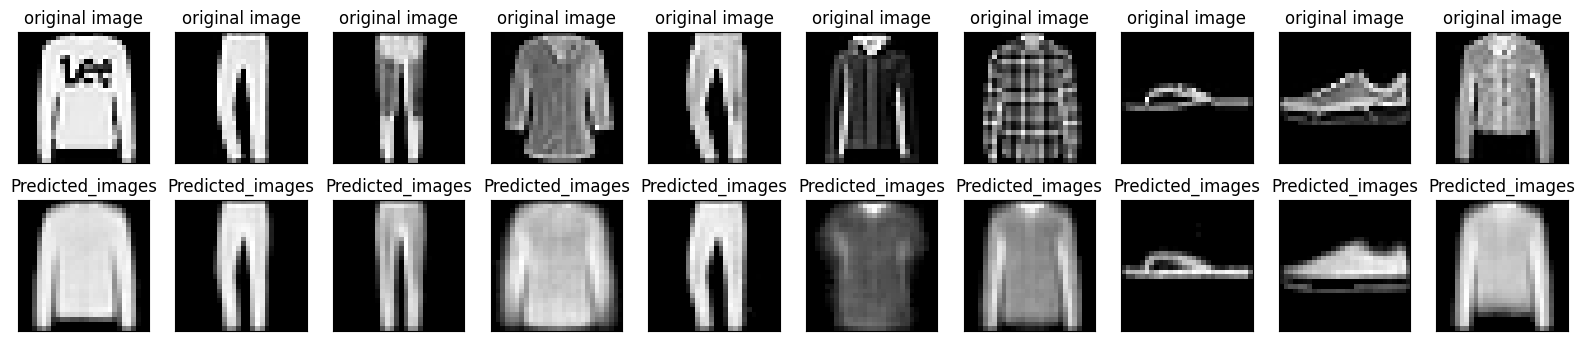

In [39]:
# Showing the original and predicted images of all 10 classes.
n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(X_test[i].reshape(28,28))
    plt.gray()
    plt.title('original image')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(prediction_data_vae[i].reshape(28,28))
    plt.gray()
    plt.title('Predicted_images')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### Exercise_3 on Variational_autoencoder

---



1. Build a more complicated model based on your understanding that generates more accurate model.

2. How many parameters does your model have?  How does that compare to the previous model?

3. Train it for 50 epochs.  What do you notice about the training time, loss and accuracy numbers (on both the training and validation sets)?

In [41]:
# Please provide your solution here
# Create model_3 to show results
# also plot the original and reconstructed images
from tensorflow.keras.layers import Lambda, Dense, Flatten, Reshape, Conv2DTranspose, Input
import tensorflow.keras.backend as K
import tensorflow as tf
from tensorflow.keras.models import Model

latent_dim = 2

# Sampling function for VAE
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
    return z_mean + K.exp(z_log_var / 2) * epsilon

# Encoder
inputs = Input(shape=(28, 28, 1))
x = Conv2D(64, 3, activation='relu', padding='same')(inputs)
x = Conv2D(128, 3, activation='relu', strides=2, padding='same')(x)
x = Conv2D(128, 3, activation='relu', strides=2, padding='same')(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)

z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)
z = Lambda(sampling)([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
latent_inputs = Input(shape=(latent_dim,))
x = Dense(7*7*128, activation='relu')(latent_inputs)
x = Reshape((7, 7, 128))(x)
x = Conv2DTranspose(128, 3, activation='relu', strides=2, padding='same')(x)
x = Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
outputs = Conv2DTranspose(1, 3, activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, outputs, name='decoder')

# VAE as a Model subclass
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(
                tf.reshape(inputs, [-1, 28*28]),
                tf.reshape(reconstruction, [-1, 28*28])
            )
        ) * (28 * 28)

        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss)
        self.loss_tracker.update_state(total_loss)
        return reconstruction

    @property
    def metrics(self):
        return [self.loss_tracker]

# Instantiate the VAE
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

# Train the VAE
vae.fit(x_train, epochs=50, batch_size=64, validation_data=(x_test, None))


Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 17ms/step - loss: 323.5208 - val_loss: 269.3731
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 266.8041 - val_loss: 264.7712
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 263.4410 - val_loss: 263.1411
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 260.7395 - val_loss: 261.1673
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 259.3236 - val_loss: 261.0806
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 258.6460 - val_loss: 259.2310
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 257.5201 - val_loss: 259.1763
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 256.6350 - val_loss: 258.2924
Epoch 9/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 256.4565 - val_loss: 257.6325
Epoch 10/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 256.2842 - val_loss: 257.7848
Epoch 11/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 255.8471 - val_l